In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define path to the pre-processed SMARD dataset
file_path = (
    "/content/drive/MyDrive/Colab Notebooks/SMARD_Cleaned_20260806_20260816.csv"
)

# Verify file existence
if os.path.exists(file_path):
  print("Dataset found successfully! Proceeding with data loading...")
else:
  print(
      "File not found! Please verify the folder structure in your Google Drive."
  )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset found successfully! Proceeding with data loading...


--- Portfolio Risk Metrics (95% Confidence Level) ---
Mean Expected Daily Revenue: €2,517.21
Value at Risk (VaR 95%):     €1,759.68 (Worst-case threshold)
Conditional VaR (CVaR 95%):  €1,574.58 (Average of the worst-case scenarios)
Maximum Potential Loss (from mean to CVaR): €942.63


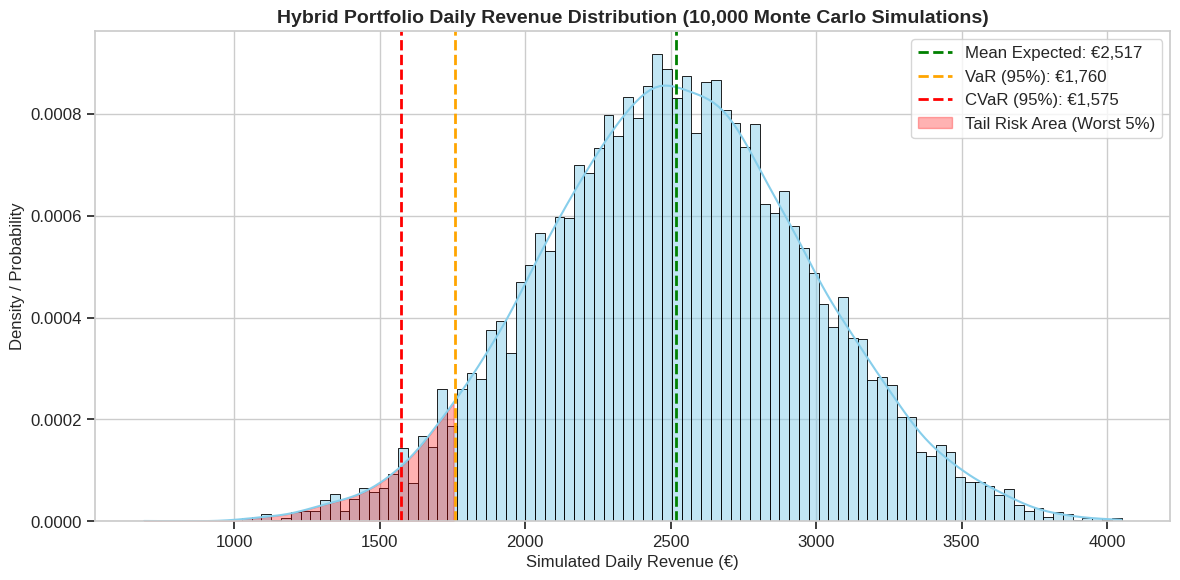

In [3]:
# ==============================================================================
# Hybrid Asset Portfolio Risk & CVaR Evaluator
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# تنظیمات ظاهری نمودارها
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.1)

# ------------------------------------------------------------------------------
# 1. شبیه‌سازی داده‌های تاریخی (Historical Data Simulation)
# ------------------------------------------------------------------------------
# فرض می‌کنیم داده‌های درآمد روزانه (یورو) برای یک سال گذشته (365 روز) را داریم.
np.random.seed(42)
days = 365

# درآمد خورشیدی در بازار روز-پیش (نوسانات بالا به دلیل تغییرات آب و هوا)
solar_da_rev = np.random.normal(loc=1200, scale=400, size=days)
# درآمد آربیتراژ باتری (نوسانات متوسط)
bess_arb_rev = np.random.normal(loc=500, scale=200, size=days)
# درآمد باتری در بازار خدمات جانبی aFRR (پایدارتر اما با ریسک فعال‌سازی)
bess_afrr_rev = np.random.normal(loc=800, scale=150, size=days)

# ساخت دیتافریم پورتفولیو
df_historical = pd.DataFrame({
    'Solar_DA': solar_da_rev,
    'BESS_Arbitrage': bess_arb_rev,
    'BESS_aFRR': bess_afrr_rev
})

# محاسبه درآمد کل پورتفولیو در هر روز
df_historical['Total_Portfolio_Revenue'] = df_historical.sum(axis=1)

# ------------------------------------------------------------------------------
# 2. شبیه‌سازی مونت‌کارلو (Monte Carlo Simulation)
# ------------------------------------------------------------------------------
# محاسبه میانگین و ماتریس کوواریانس دارایی‌ها برای درک همبستگی آن‌ها
mean_returns = df_historical[['Solar_DA', 'BESS_Arbitrage', 'BESS_aFRR']].mean()
cov_matrix = df_historical[['Solar_DA', 'BESS_Arbitrage', 'BESS_aFRR']].cov()

# تولید 10,000 سناریوی تصادفی برای روز آینده بر اساس توزیع نرمال چندمتغیره
num_simulations = 10000
simulated_revenues = np.random.multivariate_normal(mean_returns, cov_matrix, num_simulations)

# محاسبه درآمد کل پورتفولیو در هر سناریو
portfolio_simulated_rev = np.sum(simulated_revenues, axis=1)

# ------------------------------------------------------------------------------
# 3. محاسبه معیارهای ریسک: VaR و CVaR
# ------------------------------------------------------------------------------
confidence_level = 0.95

# مرتب‌سازی درآمدهای شبیه‌سازی شده از کمترین به بیشترین
sorted_revenues = np.sort(portfolio_simulated_rev)

# محاسبه ایندکس مربوط به صدک 5 درصد (بدترین 5 درصد سناریوها)
index_at_risk = int((1 - confidence_level) * num_simulations)

# Value at Risk (VaR): آستانه درآمد در بدترین 5% مواقع
VaR_95 = sorted_revenues[index_at_risk]

# Conditional Value at Risk (CVaR): میانگین درآمد در بدترین 5% مواقع
CVaR_95 = sorted_revenues[:index_at_risk].mean()

mean_expected_revenue = portfolio_simulated_rev.mean()

print(f"--- Portfolio Risk Metrics (95% Confidence Level) ---")
print(f"Mean Expected Daily Revenue: €{mean_expected_revenue:,.2f}")
print(f"Value at Risk (VaR 95%):     €{VaR_95:,.2f} (Worst-case threshold)")
print(f"Conditional VaR (CVaR 95%):  €{CVaR_95:,.2f} (Average of the worst-case scenarios)")
print(f"Maximum Potential Loss (from mean to CVaR): €{mean_expected_revenue - CVaR_95:,.2f}")

# ------------------------------------------------------------------------------
# 4. مصورسازی نتایج (Visualization)
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))

# رسم هیستوگرام توزیع درآمدهای شبیه‌سازی شده
sns.histplot(portfolio_simulated_rev, bins=100, kde=True, color='skyblue', stat='density', ax=ax)

# خطوط راهنما برای میانگین، VaR و CVaR
ax.axvline(mean_expected_revenue, color='green', linestyle='dashed', linewidth=2, label=f'Mean Expected: €{mean_expected_revenue:,.0f}')
ax.axvline(VaR_95, color='orange', linestyle='dashed', linewidth=2, label=f'VaR (95%): €{VaR_95:,.0f}')
ax.axvline(CVaR_95, color='red', linestyle='dashed', linewidth=2, label=f'CVaR (95%): €{CVaR_95:,.0f}')

# هایلایت کردن ناحیه خطر (Tail Risk)
kde_x, kde_y = ax.lines[0].get_data()
ax.fill_between(kde_x, kde_y, where=(kde_x < VaR_95), color='red', alpha=0.3, label='Tail Risk Area (Worst 5%)')

ax.set_title('Hybrid Portfolio Daily Revenue Distribution (10,000 Monte Carlo Simulations)', fontsize=14, fontweight='bold')
ax.set_xlabel('Simulated Daily Revenue (€)', fontsize=12)
ax.set_ylabel('Density / Probability', fontsize=12)
ax.legend(loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

✅ Table Saved: outputs/portfolio_risk_metrics.csv
✅ Table Saved: outputs/simulated_revenues_10k.csv
✅ Graph Saved: outputs/portfolio_risk_distribution.png
✅ Graph Saved: outputs/portfolio_risk_distribution.pdf


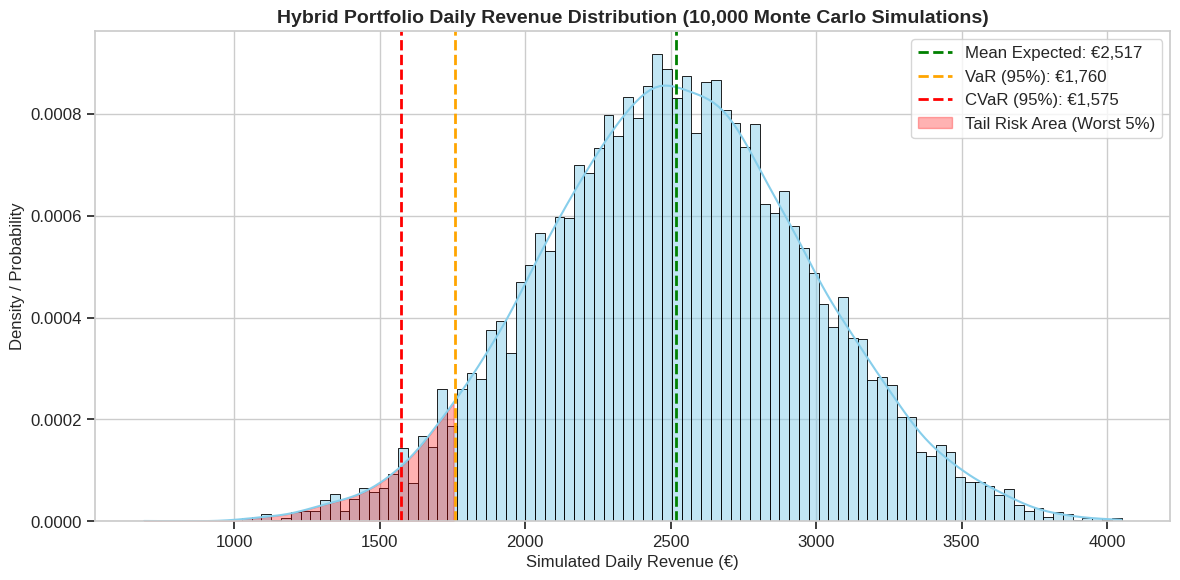

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. ساخت دایرکتوری خروجی‌ها (اگر وجود نداشته باشد ساخته می‌شود)
output_dir = "outputs"
os.makedirs(output_dir, exist_ok=True)

# تنظیمات استایل گرافیک
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.1)

# 2. تولید داده‌ها و شبیه‌سازی مونت‌کارلو (مانند قبل)
np.random.seed(42)
days = 365
df_historical = pd.DataFrame({
    'Solar_DA': np.random.normal(1200, 400, days),
    'BESS_Arbitrage': np.random.normal(500, 200, days),
    'BESS_aFRR': np.random.normal(800, 150, days)
})
df_historical['Total_Portfolio_Revenue'] = df_historical.sum(axis=1)

mean_returns = df_historical[['Solar_DA', 'BESS_Arbitrage', 'BESS_aFRR']].mean()
cov_matrix = df_historical[['Solar_DA', 'BESS_Arbitrage', 'BESS_aFRR']].cov()

num_simulations = 10000
simulated_revenues = np.random.multivariate_normal(mean_returns, cov_matrix, num_simulations)
portfolio_simulated_rev = np.sum(simulated_revenues, axis=1)

# 3. محاسبه متریک‌های VaR و CVaR
confidence_level = 0.95
sorted_revenues = np.sort(portfolio_simulated_rev)
index_at_risk = int((1 - confidence_level) * num_simulations)

VaR_95 = sorted_revenues[index_at_risk]
CVaR_95 = sorted_revenues[:index_at_risk].mean()
mean_expected = portfolio_simulated_rev.mean()

# ==============================================================================
# بخش ذخیره‌سازی خروجی‌ها (Exporting Data & Plots)
# ==============================================================================

# 4. ذخیره جداول به فرمت CSV
metrics_df = pd.DataFrame({
    "Risk_Metric": ["Mean Expected Daily Revenue", "Value at Risk (95%)", "Conditional VaR (95%)", "Max Potential Loss"],
    "Value_EUR": [round(mean_expected, 2), round(VaR_95, 2), round(CVaR_95, 2), round(mean_expected - CVaR_95, 2)]
})
metrics_csv_path = os.path.join(output_dir, "portfolio_risk_metrics.csv")
metrics_df.to_csv(metrics_csv_path, index=False)
print(f"✅ Table Saved: {metrics_csv_path}")

sim_df = pd.DataFrame({"Simulated_Total_Revenue": portfolio_simulated_rev})
sim_csv_path = os.path.join(output_dir, "simulated_revenues_10k.csv")
sim_df.to_csv(sim_csv_path, index=False)
print(f"✅ Table Saved: {sim_csv_path}")

# 5. رسم و ذخیره گراف‌ها به فرمت PNG و PDF
fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(portfolio_simulated_rev, bins=100, kde=True, color='skyblue', stat='density', ax=ax)

ax.axvline(mean_expected, color='green', linestyle='dashed', linewidth=2, label=f'Mean Expected: €{mean_expected:,.0f}')
ax.axvline(VaR_95, color='orange', linestyle='dashed', linewidth=2, label=f'VaR (95%): €{VaR_95:,.0f}')
ax.axvline(CVaR_95, color='red', linestyle='dashed', linewidth=2, label=f'CVaR (95%): €{CVaR_95:,.0f}')

kde_x, kde_y = ax.lines[0].get_data()
ax.fill_between(kde_x, kde_y, where=(kde_x < VaR_95), color='red', alpha=0.3, label='Tail Risk Area (Worst 5%)')

ax.set_title('Hybrid Portfolio Daily Revenue Distribution (10,000 Monte Carlo Simulations)', fontsize=14, fontweight='bold')
ax.set_xlabel('Simulated Daily Revenue (€)', fontsize=12)
ax.set_ylabel('Density / Probability', fontsize=12)
ax.legend(loc='upper right', frameon=True)
plt.tight_layout()

# ذخیره گراف با کیفیت 300dpi برای استفاده در لینکدین و گزارش‌ها
plot_png_path = os.path.join(output_dir, "portfolio_risk_distribution.png")
plot_pdf_path = os.path.join(output_dir, "portfolio_risk_distribution.pdf")

plt.savefig(plot_png_path, dpi=300, bbox_inches='tight')
plt.savefig(plot_pdf_path, dpi=300, bbox_inches='tight')
print(f"✅ Graph Saved: {plot_png_path}")
print(f"✅ Graph Saved: {plot_pdf_path}")

# نمایش نهایی در خود ژوپیتر
plt.show()